# Job Market Intelligence — Exploratory Data Analysis
Comprehensive EDA for the job market dataset.

# 1. Load libraries

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_and_prepare
from src.utils import logger

In [3]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
OUTPUT_DIR = Path.cwd().parent / "visuals"
OUTPUT_DIR.mkdir(exist_ok=True)

In [4]:
# Load Data
df_all, df_dsml = load_and_prepare()

2026-08-13 03:35:38,247 [INFO] job_market_v4: All jobs cleaned: 555 rows


2026-08-13 03:35:38,258 [INFO] job_market_v4: DS/ML/DL subset: 411 rows in 5 fields


2026-08-13 03:35:38,264 [INFO] job_market_v4: Saved all_jobs.csv (555 rows) + ds_ml_dl_jobs.csv (411 rows)


## 2. All Jobs Overview

In [5]:
print(f"Shape: {df_all.shape}")
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nDtypes:\n{df_all.dtypes}")

Shape: (555, 11)

Columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Dtypes:
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object


In [6]:
print(f"\nFirst 5 rows:\n{df_all.head().to_string()}")


First 5 rows:
   work_year experience_level employment_type                   job_title  salary salary_currency  salary_in_usd employee_residence  remote_ratio company_location company_size
0       2020        Mid Level              FT              Data Scientist   70000             EUR          79833            Germany             0          Germany            L
1       2020     Senior Level              FT  Machine Learning Scientist  260000             USD         260000              Japan             0            Japan            S
2       2020     Senior Level              FT           Big Data Engineer   85000             GBP         109024     United Kingdom            50   United Kingdom            M
3       2020        Mid Level              FT        Product Data Analyst   20000             USD          20000           Honduras             0         Honduras            S
4       2020     Senior Level              FT   Machine Learning Engineer  150000             USD        

In [7]:
pd.options.display.float_format = '{:,.2f}'.format
print(f"\nDescribe:\n{df_all.describe().round(2).to_string()}")



Describe:
       work_year        salary  salary_in_usd  remote_ratio
count     555.00        555.00         555.00        555.00
mean    2,021.37    336,667.63     105,062.78         69.64
std         0.69  1,614,186.39      58,981.19         40.99
min     2,020.00      4,000.00       2,859.00          0.00
25%     2,021.00     66,110.00      60,000.00         50.00
50%     2,021.00    110,000.00     100,000.00        100.00
75%     2,022.00    160,000.00     145,500.00        100.00
max     2,022.00 30,400,000.00     276,000.00        100.00


## 3. Missing Values

In [8]:
missing = df_all.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(missing.to_string())
else:
    print(" No missing values")

 No missing values


## 4. Categorical Distributions

In [9]:
categorical_cols = ["experience_level", "employment_type", "company_size", "remote_ratio", "company_location"]
for col in categorical_cols:
    if col in df_all.columns:
        print(f"\n--- {col} ---")
        print(df_all[col].value_counts().head(10).to_string())


--- experience_level ---
experience_level
Senior Level       240
Mid Level          205
Entry Level         88
Executive Level     22

--- employment_type ---
employment_type
FT    537
PT     10
CT      4
FL      4

--- company_size ---
company_size
M    288
L    186
S     81

--- remote_ratio ---
remote_ratio
100    338
0      120
50      97

--- company_location ---
company_location
United States     308
United Kingdom     46
Canada             28
Germany            27
India              24
France             15
Spain              14
Greece             10
Japan               6
Netherlands         4


## 5. Salary by Experience Level

In [10]:
salary_exp = df_all.groupby("experience_level")["salary_in_usd"].agg(["mean", "median", "min", "max", "count"]).round(0)
print(salary_exp.to_string())

                       mean     median    min     max  count
experience_level                                            
Entry Level       61,643.00  56,500.00   4000  250000     88
Executive Level  159,963.00 151,834.00  69741  250000     22
Mid Level         82,624.00  75,774.00   2859  270000    205
Senior Level     135,117.00 135,000.00  18907  276000    240


## 6. Salary by Company Size

In [11]:
salary_size = df_all.groupby("company_size")["salary_in_usd"].agg(["mean", "median", "count"]).round(0)
print(salary_size.to_string())

                   mean     median  count
company_size                             
L            106,561.00  95,389.00    186
M            112,917.00 109,280.00    288
S             73,698.00  65,000.00     81


## 7. DS / ML / DL Subset

In [12]:
print(f"Shape: {df_dsml.shape}")

Shape: (411, 12)


In [13]:
print(f"\nDS/ML Fields:\n{df_dsml['ds_ml_field'].value_counts().to_string()}")


DS/ML Fields:
ds_ml_field
Data Science        175
Data Engineering    145
Machine Learning     65
Research             15
AI Specialized       11


In [14]:
print(f"\nSalary by DS/ML Field:")
dsml_salary = df_dsml.groupby("ds_ml_field")["salary_in_usd"].agg(["mean", "median", "count"]).round(0).sort_values("median", ascending=False)
print(dsml_salary.to_string())


Salary by DS/ML Field:
                       mean     median  count
ds_ml_field                                  
Data Science     110,297.00 105,000.00    175
Data Engineering 108,785.00 103,160.00    145
Machine Learning 106,279.00  87,425.00     65
Research          86,287.00  69,999.00     15
AI Specialized    56,810.00  37,236.00     11


## 8. Top 20 Job Titles

In [15]:
top_titles = df_all["job_title"].value_counts().head(20)
print(top_titles.to_string())

job_title
Data Scientist                129
Data Engineer                 120
Data Analyst                   82
Machine Learning Engineer      39
Research Scientist             15
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
AI Scientist                    7
Data Analytics Manager          7
Lead Data Engineer              6
BI Data Analyst                 6
ML Engineer                     6
Computer Vision Engineer        6
Principal Data Scientist        6
Director of Data Science        6
Business Data Analyst           5
Data Engineering Manager        5


## 9. Salary Trends by Work Year

In [16]:
year_salary = df_all.groupby("work_year")["salary_in_usd"].agg(["mean", "median", "count"]).round(0)
print(year_salary.to_string())

                mean     median  count
work_year                             
2020       82,776.00  72,000.00     69
2021       92,363.00  81,000.00    211
2022      120,399.00 118,187.00    275


## 10. Visualizations

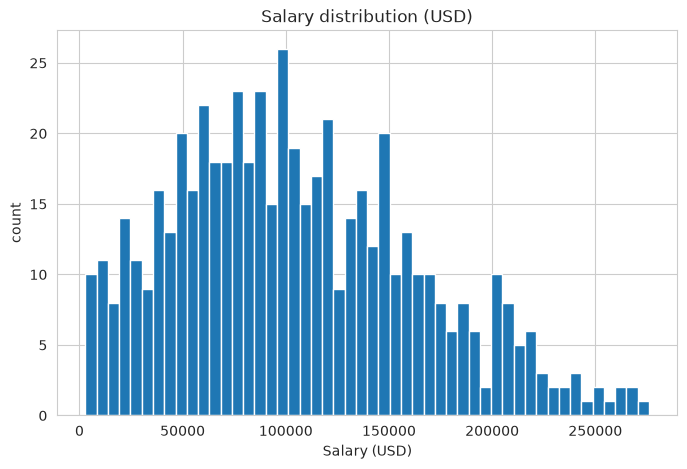

In [17]:
# Chart 1: Salary Distribution
fig, ax = plt.subplots(figsize=(8, 5))
df_all["salary_in_usd"].hist(bins=50, edgecolor="white", ax=ax)
ax.set_title("Salary distribution (USD)")
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("count")
fig.savefig(OUTPUT_DIR / "salary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

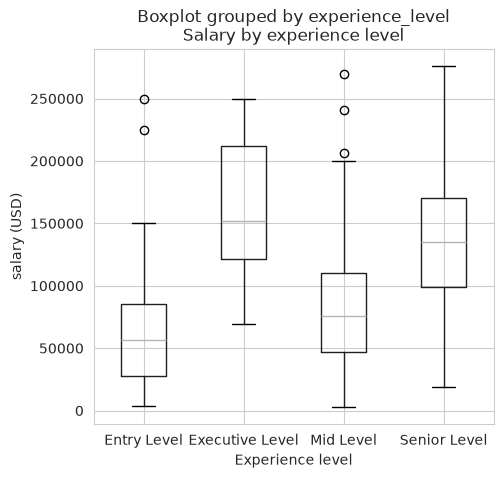

In [18]:
# Chart 2: Salary by Experience (Boxplot)
fig, ax = plt.subplots(figsize=(5, 5))
df_all.boxplot(column="salary_in_usd", by="experience_level", ax=ax)
ax.set_title("Salary by experience level")
ax.set_xlabel("Experience level")
ax.set_ylabel("salary (USD)")
fig.savefig(OUTPUT_DIR / "salary_by_experience_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

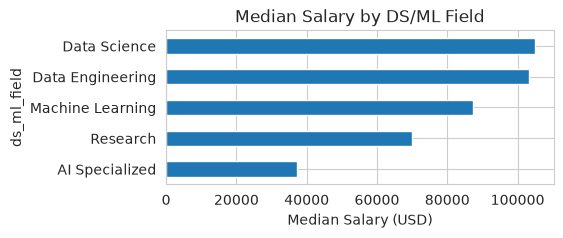

In [19]:
# Chart 3: Salary by DS/ML Field (Bar)
fig, ax = plt.subplots(figsize=(5, 2))
dsml_salary_plot = df_dsml.groupby("ds_ml_field")["salary_in_usd"].median().sort_values()
dsml_salary_plot.plot(kind="barh", ax=ax)
ax.set_title("Median Salary by DS/ML Field")
ax.set_xlabel("Median Salary (USD)")
fig.savefig(OUTPUT_DIR / "salary_by_dsml_field.png", dpi=150, bbox_inches="tight")
plt.show()

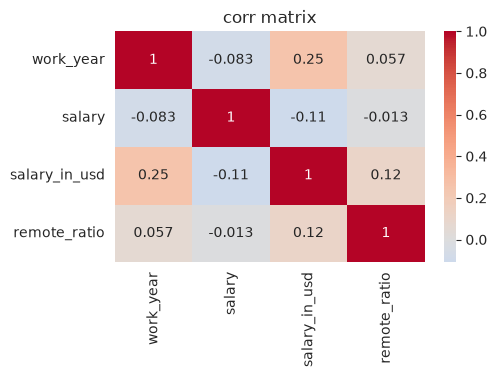

In [20]:
# Chart 4: Correlation Heatmap
numeric_cols = df_all.select_dtypes(include=[np.number]).columns
fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(df_all[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("corr matrix")
fig.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Key Insights

In [21]:
print("Summary\n")
print(f" Total jobs analyzed: {len(df_all):,}")
print(f" DS/ML/DL specific jobs: {len(df_dsml):,}")
print(f" Median salary (all jobs): ${df_all['salary_in_usd'].median():,.0f}")
print(f" Median salary (DS/ML/DL): ${df_dsml['salary_in_usd'].median():,.0f}")
print(f" Most common experience: {df_all['experience_level'].mode().iloc[0]}")
print(f" Year range: {df_all['work_year'].min()} - {df_all['work_year'].max()}")
print(f" Countries represented: {df_all['company_location'].nunique()}")
print(f" Unique job titles: {df_all['job_title'].nunique()}")
print(f" Top DS/ML field: {df_dsml['ds_ml_field'].value_counts().index[0]}")
print("\n EDA completed and charts saved to visuals/")

Summary

 Total jobs analyzed: 555
 DS/ML/DL specific jobs: 411
 Median salary (all jobs): $100,000
 Median salary (DS/ML/DL): $100,000
 Most common experience: Senior Level
 Year range: 2020 - 2022
 Countries represented: 50
 Unique job titles: 49
 Top DS/ML field: Data Science

 EDA completed and charts saved to visuals/


# Job Market Intelligence — Exploratory Data Analysis
Comprehensive EDA for the job market dataset.

In [22]:
# Adjust path to find src/ from the notebooks/ folder
sys.path.insert(0, str(Path.cwd().parent))

In [23]:
# Config
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
OUTPUT_DIR = Path.cwd().parent / "visuals"
OUTPUT_DIR.mkdir(exist_ok=True)

In [24]:
# Load Data
df_all, df_dsml = load_and_prepare()

2026-08-13 03:35:39,201 [INFO] job_market_v4: All jobs cleaned: 555 rows


2026-08-13 03:35:39,206 [INFO] job_market_v4: DS/ML/DL subset: 411 rows in 5 fields


2026-08-13 03:35:39,209 [INFO] job_market_v4: Saved all_jobs.csv (555 rows) + ds_ml_dl_jobs.csv (411 rows)


## 12. All Jobs Overview

In [25]:
print(f"Shape: {df_all.shape}")

Shape: (555, 11)


In [26]:
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nDtypes:\n{df_all.dtypes}")
print(f"\nFirst 5 rows:\n{df_all.head().to_string()}")
print(f"\nDescribe:\n{df_all.describe().round(2).to_string()}")


Columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Dtypes:
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

First 5 rows:
   work_year experience_level employment_type                   job_title  salary salary_currency  salary_in_usd employee_residence  remote_ratio company_location company_size
0       2020        Mid Level              FT              Data Scientist   70000             EUR          79833            Germany             0          Germany            L
1       2020     Senior Level              FT  Machine Learning Scientist  260000             USD         